In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os

CONFIGURATION - FIXED FOR YOUR DATA

In [ ]:
TEXT_DIR = "/content/drive/MyDrive/threec/processed"
AUDIO_DIR = "/content/drive/MyDrive/threec/processed_audio"
SAVE_DIR = "/content/drive/MyDrive/threec/audio_checkpoints"

BATCH_SIZE = 8
PAYLOAD_SIZE = 4096
AUDIO_LENGTH = 340  # <<<< FIXED: Changed from 65536 to match your data
SAMPLE_RATE = 16000
NUM_EPOCHS = 20
NUM_WORKERS = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*70)
print("AUDIO STEGANOGRAPHY TRAINING")
print("="*70)
print(f"Device: {device}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Payload size: {PAYLOAD_SIZE}")
print(f"Audio length: {AUDIO_LENGTH} samples ({AUDIO_LENGTH/SAMPLE_RATE:.3f}s)")
print(f"Epochs: {NUM_EPOCHS}")

os.makedirs(SAVE_DIR, exist_ok=True)

🎵 AUDIO STEGANOGRAPHY TRAINING
📱 Device: cpu
📦 Batch size: 8
📝 Payload size: 4096
🎵 Audio length: 340 samples (0.021s)
🔢 Epochs: 20


DATASET

In [ ]:
class AudioSteganographyDataset(Dataset):
    def __init__(self, audio_data, labels, payloads, mode='train'):
        self.audio_data = audio_data
        self.labels = labels
        self.payloads = payloads
        self.mode = mode
        print(f"✓ {mode.upper()} Dataset: {audio_data.shape}")

    def __len__(self):
        return len(self.audio_data)

    def __getitem__(self, idx):
        cover = torch.tensor(self.audio_data[idx], dtype=torch.float32).unsqueeze(0)
        payload_idx = np.random.randint(0, len(self.payloads))
        payload = torch.tensor(self.payloads[payload_idx], dtype=torch.float32)

        if payload.shape[0] != PAYLOAD_SIZE:
            if payload.shape[0] < PAYLOAD_SIZE:
                padding = torch.zeros(PAYLOAD_SIZE - payload.shape[0])
                payload = torch.cat([payload, padding])
            else:
                payload = payload[:PAYLOAD_SIZE]

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return {'cover': cover, 'payload': payload, 'label': label, 'idx': idx}

print("✓ Dataset class defined!")

✓ Dataset class defined!


LOAD DATA

In [ ]:
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

print("\nLoading payloads...")
payloads = np.load(f"{TEXT_DIR}/payload_arrays.npy")
print(f"✓ Loaded {len(payloads)} payloads, shape: {payloads.shape}")

print("\nLoading audio files...")
train_audio = np.load(f"{AUDIO_DIR}/X_train_audio.npy")
train_labels = np.load(f"{AUDIO_DIR}/y_train_audio.npy")
val_audio = np.load(f"{AUDIO_DIR}/X_val_audio.npy")

# Handle missing val labels
try:
    val_labels = np.load(f"{AUDIO_DIR}/y_val_audio.npy")
except FileNotFoundError:
    print("Warning: y_val_audio.npy not found. Creating dummy labels...")
    val_labels = np.zeros(len(val_audio), dtype=np.int64)

test_audio = np.load(f"{AUDIO_DIR}/X_test_audio.npy")
test_labels = np.load(f"{AUDIO_DIR}/y_test_audio.npy")

print(f"✓ Train: {train_audio.shape}, Labels: {train_labels.shape}")
print(f"✓ Val: {val_audio.shape}, Labels: {val_labels.shape}")
print(f"✓ Test: {test_audio.shape}, Labels: {test_labels.shape}")



📦 LOADING DATA

Loading payloads...
✓ Loaded 999 payloads, shape: (999, 4096)

Loading audio files...
✓ Train: (1008, 340), Labels: (1008,)
✓ Val: (144, 340), Labels: (144,)
✓ Test: (288, 340), Labels: (288,)


CREATE DATASETS AND DATALOADERS

In [ ]:
print("\n" + "="*70)
print("CREATING DATALOADERS")
print("="*70)

train_dataset = AudioSteganographyDataset(train_audio, train_labels, payloads, 'train')
val_dataset = AudioSteganographyDataset(val_audio, val_labels, payloads, 'val')
test_dataset = AudioSteganographyDataset(test_audio, test_labels, payloads, 'test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"✓ Train: {len(train_loader)} batches")
print(f"✓ Val: {len(val_loader)} batches")
print(f"✓ Test: {len(test_loader)} batches")
print("\nDataLoaders ready!")


📦 CREATING DATALOADERS
✓ TRAIN Dataset: (1008, 340)
✓ VAL Dataset: (144, 340)
✓ TEST Dataset: (288, 340)
✓ Train: 126 batches
✓ Val: 18 batches
✓ Test: 36 batches

✅ DataLoaders ready!


MODEL BLOCKS

In [ ]:
class Conv1dBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, s, p),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class ResidualBlock(nn.Module):
    def __init__(self, ch, k=3):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, k, padding=k//2)
        self.bn1 = nn.BatchNorm1d(ch)
        self.conv2 = nn.Conv1d(ch, ch, k, padding=k//2)
        self.bn2 = nn.BatchNorm1d(ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + residual)

class PayloadEmbedding(nn.Module):
    def __init__(self, payload_bits=4096, audio_len=340, embed_ch=64):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(payload_bits, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, audio_len)
        )
        self.conv = nn.Sequential(
            Conv1dBlock(1, embed_ch // 2, 7, 1, 3),
            Conv1dBlock(embed_ch // 2, embed_ch, 5, 1, 2)
        )

    def forward(self, payload):
        x = self.fc(payload).unsqueeze(1)
        return self.conv(x)


ENCODER - ADJUSTED FOR SHORTER AUDIO

In [ ]:


class AudioStegoEncoder(nn.Module):
    def __init__(self, payload_bits=4096, audio_len=340):
        super().__init__()
        self.payload_embed = PayloadEmbedding(payload_bits, audio_len, 64)
        self.inc = Conv1dBlock(1 + 64, 64, 7, 1, 3)

        # Reduced downsampling since audio is short
        self.enc1 = nn.Sequential(Conv1dBlock(64, 128, 5, 1, 2), ResidualBlock(128))
        self.enc2 = nn.Sequential(Conv1dBlock(128, 256, 5, 2, 2), ResidualBlock(256))  # 340 -> 170

        self.bottleneck = nn.Sequential(ResidualBlock(256), ResidualBlock(256))

        # Matching upsampling
        self.dec2 = nn.Sequential(
            nn.ConvTranspose1d(256, 128, 4, 2, 1),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True), ResidualBlock(128)
        )  # 170 -> 340
        self.dec1 = nn.Sequential(
            Conv1dBlock(256, 64, 5, 1, 2),
            ResidualBlock(64)
        )

        self.outc = nn.Conv1d(128, 1, 7, 1, 3)
        self.tanh = nn.Tanh()

    def forward(self, cover, payload):
        payload_feat = self.payload_embed(payload)
        x = torch.cat([cover, payload_feat], dim=1)

        x0 = self.inc(x)
        x1 = self.enc1(x0)
        x2 = self.enc2(x1)

        x = self.bottleneck(x2)

        x = self.dec2(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)
        x = torch.cat([x, x0], dim=1)

        residual = self.tanh(self.outc(x)) * 0.05
        return torch.clamp(cover + residual, -1, 1)

DECODER - ADJUSTED FOR SHORTER AUDIO

In [ ]:
class AudioStegoDecoder(nn.Module):
    def __init__(self, payload_bits=4096):
        super().__init__()
        self.enc1 = nn.Sequential(Conv1dBlock(1, 64, 7, 1, 3), ResidualBlock(64))
        self.enc2 = nn.Sequential(Conv1dBlock(64, 128, 5, 2, 2), ResidualBlock(128))  # 340 -> 170
        self.enc3 = nn.Sequential(Conv1dBlock(128, 256, 5, 2, 2), ResidualBlock(256))  # 170 -> 85
        self.enc4 = nn.Sequential(Conv1dBlock(256, 512, 5, 2, 2), ResidualBlock(512))  # 85 -> 42

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(512, 1024), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(1024, 1024), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(1024, payload_bits)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, stego):
        x = self.enc1(stego)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.sigmoid(self.fc(x))

print("Models defined!")

✓ Models defined!


CREATE MODELS

In [ ]:
print("\n" + "="*70)
print("CREATING MODELS")
print("="*70)

encoder = AudioStegoEncoder(PAYLOAD_SIZE, AUDIO_LENGTH).to(device)
decoder = AudioStegoDecoder(PAYLOAD_SIZE).to(device)

enc_p = sum(p.numel() for p in encoder.parameters())
dec_p = sum(p.numel() for p in decoder.parameters())

print(f"✓ Encoder: {enc_p:,} parameters")
print(f"✓ Decoder: {dec_p:,} parameters")
print(f"✓ Total: {enc_p + dec_p:,} parameters\nModels created!")


🏗️  CREATING MODELS
✓ Encoder: 6,411,669 parameters
✓ Decoder: 8,731,520 parameters
✓ Total: 15,143,189 parameters
✅ Models created!


TEST FORWARD PASS

In [ ]:
print("\n" + "="*70)
print("TESTING FORWARD PASS")
print("="*70)

batch = next(iter(train_loader))
cover = batch['cover'][:2].to(device)
payload = batch['payload'][:2].to(device)

print(f"\nInput: Cover {cover.shape}, Payload {payload.shape}")

encoder.eval()
decoder.eval()

with torch.no_grad():
    stego = encoder(cover, payload)
    extracted = decoder(stego)

print(f"Output: Stego {stego.shape}, Extracted {extracted.shape}")

diff = (stego - cover).abs()
print(f"\nAudio diff: Max={diff.max():.6f}, Mean={diff.mean():.6f}")

acc = ((extracted > 0.5).float() == payload).float().mean()
print(f"Untrained accuracy: {acc.item()*100:.2f}% (should be ~50%)")
print("\nForward pass successful!")

print("\n" + "="*70)
print("🎯 READY FOR TRAINING!")
print("="*70)
print("Next steps:")
print("1. Define optimizer and loss functions")
print("2. Implement training loop")
print("3. Add validation and checkpointing")
print("4. Train the model!")


🔍 TESTING FORWARD PASS


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Input: Cover torch.Size([2, 1, 340]), Payload torch.Size([2, 4096])
Output: Stego torch.Size([2, 1, 340]), Extracted torch.Size([2, 4096])

Audio diff: Max=1.384862, Mean=0.023563
Untrained accuracy: 50.29% (should be ~50%)

✅ Forward pass successful!

🎯 READY FOR TRAINING!
Next steps:
1. Define optimizer and loss functions
2. Implement training loop
3. Add validation and checkpointing
4. Train the model!


LOSS FUNCTIONS

In [ ]:
class SpectralLoss(nn.Module):
    def __init__(self, n_ffts=[64, 128, 256]):  # Changed from [512, 1024, 2048]
        super().__init__()
        self.n_ffts = n_ffts

    def forward(self, cover, stego):
        loss = 0
        for n_fft in self.n_ffts:
            c_stft = torch.stft(cover.squeeze(1), n_fft=n_fft,
                               hop_length=n_fft//4, return_complex=True)
            s_stft = torch.stft(stego.squeeze(1), n_fft=n_fft,
                               hop_length=n_fft//4, return_complex=True)
            loss += F.l1_loss(torch.abs(c_stft), torch.abs(s_stft))
        return loss / len(self.n_ffts)

class AudioSteganographyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
        self.l1 = nn.L1Loss()
        self.spectral = SpectralLoss()
        self.w_payload = 1.0
        self.w_recon = 0.5
        self.w_spectral = 0.3

    def forward(self, cover, stego, payload_true, payload_pred):
        l_payload = self.bce(payload_pred, payload_true)
        l_recon = self.l1(stego, cover)
        l_spectral = self.spectral(cover, stego)

        total = (self.w_payload * l_payload +
                self.w_recon * l_recon +
                self.w_spectral * l_spectral)

        return total, {
            'payload': l_payload.item(),
            'reconstruction': l_recon.item(),
            'spectral': l_spectral.item(),
            'total': total.item()
        }

def calculate_metrics(cover, stego, payload_true, payload_pred):
    noise = stego - cover
    snr = 10 * torch.log10(torch.mean(cover**2) / (torch.mean(noise**2) + 1e-8))

    payload_bin = (payload_pred > 0.5).float()
    ber = (payload_bin != payload_true).float().sum() / payload_true.numel()

    return {
        'snr': snr.item(),
        'ber': ber.item(),
        'accuracy': (1.0 - ber).item()
    }

print("Loss functions defined!")

✓ Loss functions defined!


TRAINING FUNCTIONS

In [ ]:


def train_epoch(encoder, decoder, loader, criterion, enc_opt, dec_opt, device, epoch):
    encoder.train()
    decoder.train()

    total_loss = 0
    metrics = {'snr': 0, 'ber': 0, 'accuracy': 0}
    losses = {'payload': 0, 'reconstruction': 0, 'spectral': 0, 'total': 0}

    pbar = tqdm(loader, desc=f'Epoch {epoch}')

    for batch in pbar:
        cover = batch['cover'].to(device)
        payload = batch['payload'].to(device)

        stego = encoder(cover, payload)
        payload_pred = decoder(stego)

        loss, loss_dict = criterion(cover, stego, payload, payload_pred)

        enc_opt.zero_grad()
        dec_opt.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)

        enc_opt.step()
        dec_opt.step()

        with torch.no_grad():
            m = calculate_metrics(cover, stego, payload, payload_pred)

        total_loss += loss.item()
        for k in losses:
            losses[k] += loss_dict[k]
        for k in metrics:
            metrics[k] += m[k]

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{m["accuracy"]*100:.1f}%',
            'snr': f'{m["snr"]:.1f}dB'
        })

    n = len(loader)
    return (total_loss/n, {k: v/n for k,v in losses.items()},
            {k: v/n for k,v in metrics.items()})

def validate(encoder, decoder, loader, criterion, device):
    encoder.eval()
    decoder.eval()

    total_loss = 0
    metrics = {'snr': 0, 'ber': 0, 'accuracy': 0}
    losses = {'payload': 0, 'reconstruction': 0, 'spectral': 0, 'total': 0}

    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            cover = batch['cover'].to(device)
            payload = batch['payload'].to(device)

            stego = encoder(cover, payload)
            payload_pred = decoder(stego)

            loss, loss_dict = criterion(cover, stego, payload, payload_pred)
            m = calculate_metrics(cover, stego, payload, payload_pred)

            total_loss += loss.item()
            for k in losses:
                losses[k] += loss_dict[k]
            for k in metrics:
                metrics[k] += m[k]

    n = len(loader)
    return (total_loss/n, {k: v/n for k,v in losses.items()},
            {k: v/n for k,v in metrics.items()})

print("Training functions defined!")

✓ Training functions defined!


MAIN TRAINING LOOP

In [ ]:
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

criterion = AudioSteganographyLoss()
enc_opt = optim.Adam(encoder.parameters(), lr=1e-4, weight_decay=1e-5)
dec_opt = optim.Adam(decoder.parameters(), lr=1e-4, weight_decay=1e-5)

enc_sched = optim.lr_scheduler.ReduceLROnPlateau(enc_opt, 'min', factor=0.5, patience=5)
dec_sched = optim.lr_scheduler.ReduceLROnPlateau(dec_opt, 'min', factor=0.5, patience=5)

history = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_snr': [], 'val_snr': [],
    'train_ber': [], 'val_ber': []
}

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"{'='*70}")

    start = time.time()

    train_loss, train_losses, train_metrics = train_epoch(
        encoder, decoder, train_loader, criterion, enc_opt, dec_opt, device, epoch
    )

    val_loss, val_losses, val_metrics = validate(
        encoder, decoder, val_loader, criterion, device
    )

    elapsed = time.time() - start

    old_lr = enc_opt.param_groups[0]['lr']
    enc_sched.step(val_loss)
    dec_sched.step(val_loss)
    new_lr = enc_opt.param_groups[0]['lr']

    if new_lr < old_lr:
        print(f"\nLR reduced to {new_lr:.2e}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_metrics['accuracy'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['train_snr'].append(train_metrics['snr'])
    history['val_snr'].append(val_metrics['snr'])
    history['train_ber'].append(train_metrics['ber'])
    history['val_ber'].append(val_metrics['ber'])

    print(f"\nResults ({elapsed:.1f}s):")
    print(f"  Loss: {train_loss:.4f} / {val_loss:.4f}")
    print(f"  Acc: {train_metrics['accuracy']*100:.2f}% / {val_metrics['accuracy']*100:.2f}%")
    print(f"  SNR: {train_metrics['snr']:.2f} / {val_metrics['snr']:.2f} dB")

    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        torch.save({
            'epoch': epoch,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'val_accuracy': val_metrics['accuracy']
        }, f'{SAVE_DIR}/best_model.pth')
        print(f"  ✓ Best model saved! ({val_metrics['accuracy']*100:.2f}%)")

torch.save({
    'epoch': NUM_EPOCHS,
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'history': history
}, f'{SAVE_DIR}/final_model.pth')

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")


🚀 STARTING TRAINING

Epoch 1/20


Epoch 1:   0%|          | 0/126 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:730: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:836.)
  return _VF.stft(  # type: ignore[attr-defined]
Validation: 100%|██████████| 18/18 [00:04<00:00,  4.30it/s]



📊 Results (126.3s):
  Loss: 1.0645 / 0.9314
  Acc: 91.30% / 94.43%
  SNR: 5.44 / 5.33 dB
  ✓ Best model saved! (94.43%)

Epoch 2/20


Validation: 100%|██████████| 18/18 [00:04<00:00,  4.15it/s]



📊 Results (127.1s):
  Loss: 0.9698 / 0.9282
  Acc: 94.39% / 94.25%
  SNR: 5.10 / 5.32 dB

Epoch 3/20


...


📊 Results (158.7s):
  Loss: 0.9391 / 0.8960
  Acc: 94.98% / 95.21%
  SNR: 5.39 / 5.32 dB

Epoch 19/20


Validation: 100%|██████████| 18/18 [00:04<00:00,  3.62it/s]



⚠️  LR reduced to 5.00e-05

📊 Results (150.8s):
  Loss: 0.9391 / 0.8971
  Acc: 94.95% / 95.07%
  SNR: 5.34 / 5.32 dB

Epoch 20/20


Validation: 100%|██████████| 18/18 [00:03<00:00,  4.54it/s]



📊 Results (150.3s):
  Loss: 0.9383 / 0.8988
  Acc: 94.92% / 95.01%
  SNR: 5.20 / 5.32 dB

✅ TRAINING COMPLETE!

Best validation accuracy: 95.33%


PLOT RESULTS


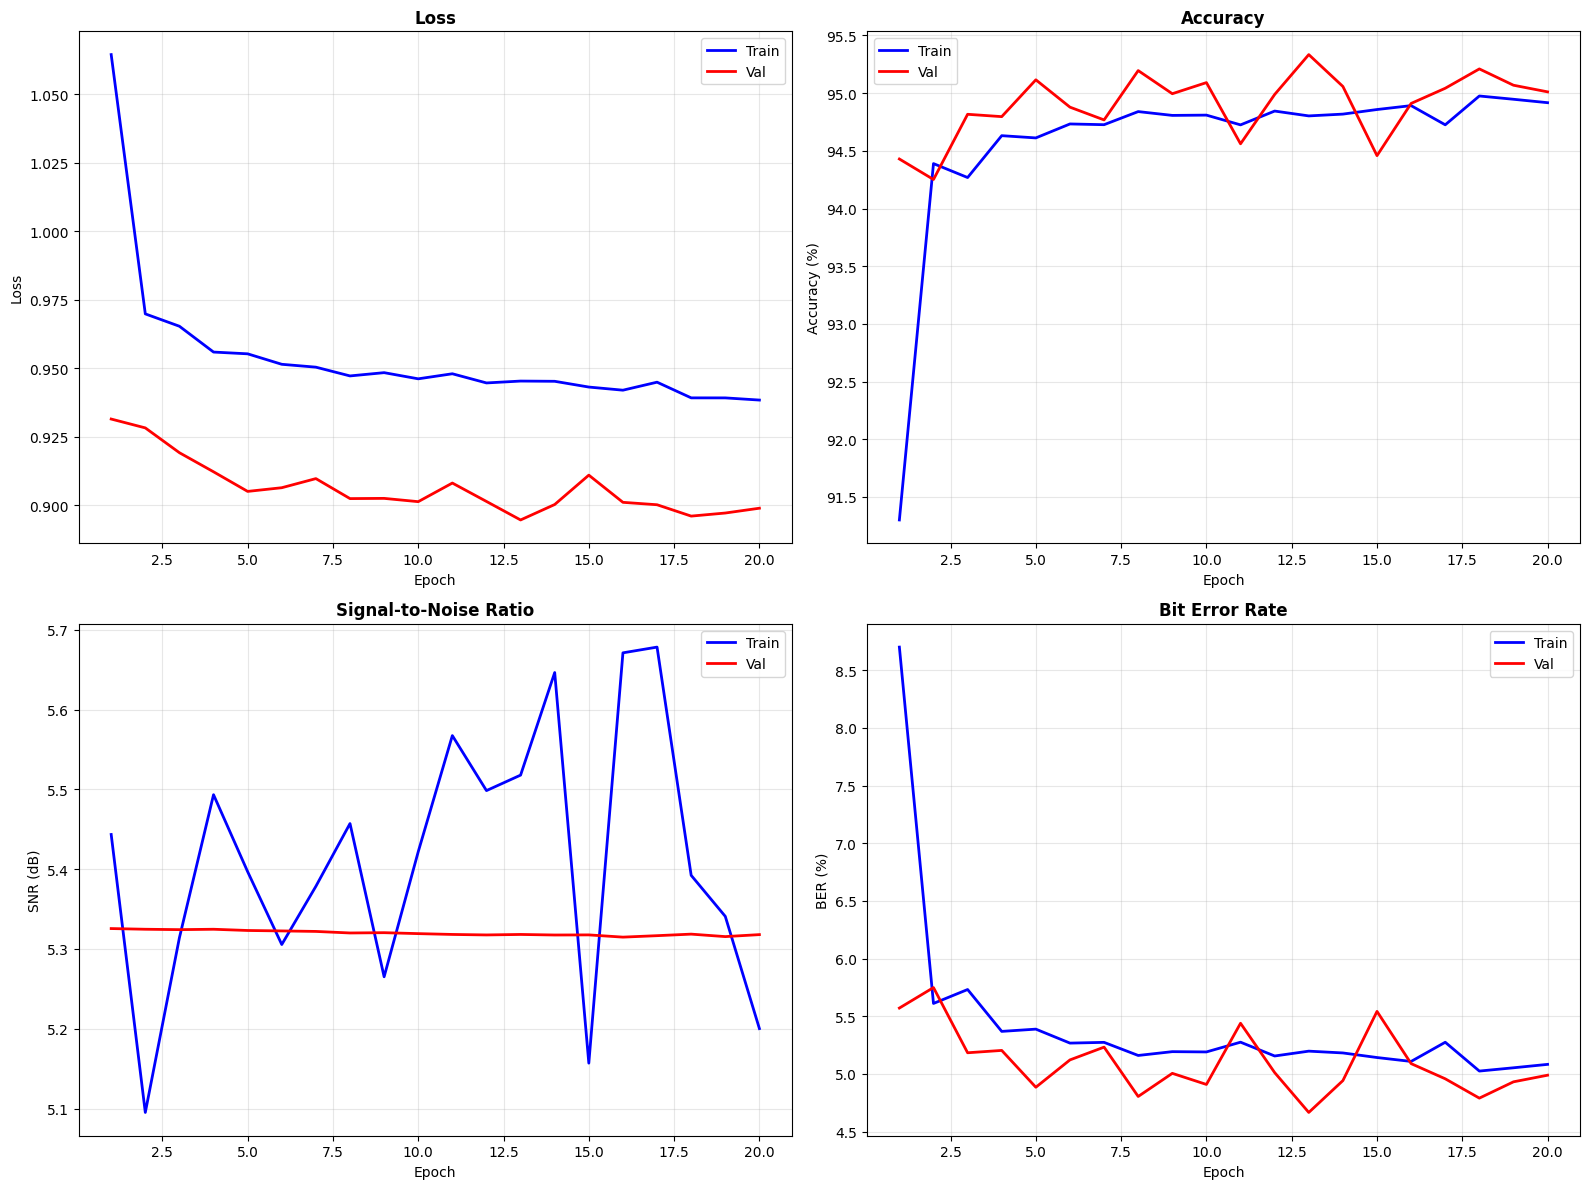

✓ History saved to /content/drive/MyDrive/threec/audio_checkpoints/training_history.png

🎉 ALL DONE!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
epochs = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, [a*100 for a in history['train_accuracy']], 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs, [a*100 for a in history['val_accuracy']], 'r-', label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, history['train_snr'], 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs, history['val_snr'], 'r-', label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('SNR (dB)')
axes[1, 0].set_title('Signal-to-Noise Ratio', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, [b*100 for b in history['train_ber']], 'b-', label='Train', linewidth=2)
axes[1, 1].plot(epochs, [b*100 for b in history['val_ber']], 'r-', label='Val', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('BER (%)')
axes[1, 1].set_title('Bit Error Rate', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_history.png', dpi=150)
plt.show()

print(f"History saved to {SAVE_DIR}/training_history.png")
print("\nALL DONE!")